# 📈 Linear Regression from Scratch
### *Implementing Gradient Descent — Just Like the Board*

---

**Student Name:** `Alishba Amjad`  
**Date:** `April 8,2026`  
**Estimated Time:** 60–90 minutes

---

### 🎯 What You Will Build

By the end of this notebook you will have:

1. **Explored** a real-world Salary vs. Experience dataset
2. **Implemented** a `LinearRegressionGD` class — your own mini ML library
3. **Trained** the model using gradient descent (the same formulas from class)
4. **Visualised** the cost curve to see convergence in action
5. **Compared** your results with `sklearn`'s built-in linear regression

> **How to use this notebook:**  
> - 📘 **Blue boxes** = demo / teaching sections — read and run them  
> - ✏️ **Yellow boxes** = your turn — fill in the `# YOUR CODE HERE` sections  
> - ✅ **Assert cells** = auto-check your answers (they should run without errors)

---


## 📦 Step 0 — Imports

Run this cell first. All libraries you need are already imported.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Pretty plots
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

print("✅ All imports successful!")


✅ All imports successful!


---
## 📊 Step 1 — The Dataset: Salary vs. Experience

We'll use a classic real-world dataset: **Years of Experience → Annual Salary (USD)**

This is perfect for linear regression because:
- There's a clear linear trend (more experience → higher salary)
- It has one input feature `x` and one output `y`
- Easy to interpret and visualise

| Column | Description |
|--------|-------------|
| `YearsExperience` | Number of years of work experience (0–11) |
| `Salary` | Annual salary in USD |

> **Dataset source:** Commonly known as `Salary_Data.csv` — widely used in ML courses.


In [3]:
# ── Real-world Salary Dataset ──────────────────────────────────────
experience = np.array([
    1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
    3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
    6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5
], dtype=float)

salary = np.array([
    39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189,
    63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940,
    91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872
], dtype=float)

print(f"Dataset loaded: {len(experience)} samples")
print(f"Experience range : {experience.min():.1f} — {experience.max():.1f} years")
print(f"Salary range     : ${salary.min():,.0f} — ${salary.max():,.0f}")


Dataset loaded: 30 samples
Experience range : 1.1 — 10.5 years
Salary range     : $37,731 — $122,391


---
## 🔍 Step 2 — Explore the Data

Before training any model, always **look at your data** first.

✏️ **YOUR TASK:**  Fill in the cells below to explore the dataset.


In [4]:
# ✏️ Task 2.1 — Print basic statistics
# Hint: use np.mean(), np.std(), np.min(), np.max()

print("=== Years of Experience ===")
print(f"  Mean  : {np.mean(experience):.2f}")  # already done as demo
print(f"  Std   : {np.std(experience):.2f}")
print(f"  Min   : {np.min(experience):.1f}")
print(f"  Max   : {np.max(experience):.1f}")

print()
print("=== Salary (USD) ===")
print(f"  Mean  : {np.mean(salary):.2f}")
print(f"  Std   : {np.std(salary):.2f}")
print(f"  Min   : {np.min(salary):.0f}")
print(f"  Max   : {np.max(salary):.0f}")


=== Years of Experience ===
  Mean  : 5.31
  Std   : 2.79
  Min   : 1.1
  Max   : 10.5

=== Salary (USD) ===
  Mean  : 76003.00
  Std   : 26953.65
  Min   : 37731
  Max   : 122391


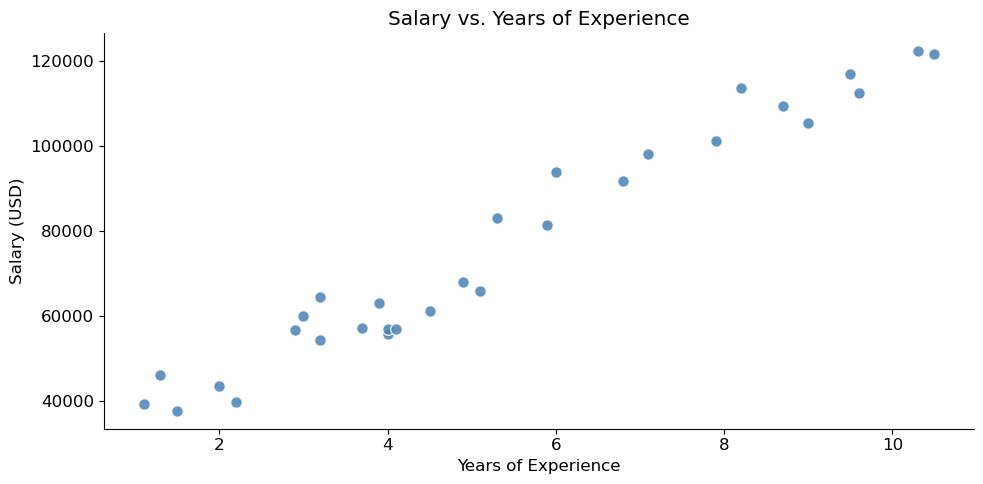

In [37]:
# ✏️ Task 2.2 — Visualise the data (scatter plot)

fig, ax = plt.subplots()
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Salary (USD)")
ax.set_title("Salary vs. Years of Experience")
ax.scatter(experience, salary, color='steelblue', edgecolors='white', s=70, alpha=0.85)

plt.tight_layout()
plt.show()

# Question: Does the data look linear? Would a straight line fit well?
# Yes, the data looks linear because there is a clear increase in salary as experience increases; 
# therefore, a straight line will fit it perfectly.

---
## ⚙️ Step 3 — Feature Scaling (Pre-processing)

### 📘 DEMO — Why scale features?

Gradient descent works much better when features are on a **similar scale**.

Without scaling:
- `experience` ≈ 1–10
- `salary` ≈ 39,000–122,000

The cost landscape is a very elongated ellipse → gradient descent zigzags and converges slowly.

With scaling (normalisation), the bowl is more circular → faster, smoother convergence.

**We use Min-Max normalisation:**

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

This maps every value to the range **[0, 1]**.


In [38]:
# ── 📘 DEMO: How Min-Max Scaling works ──────────────────────────────
demo_values = np.array([10.0, 20.0, 30.0, 40.0, 50.0])

x_min = demo_values.min()
x_max = demo_values.max()
scaled = (demo_values - x_min) / (x_max - x_min)

print("Original:", demo_values)
print("Scaled  :", scaled)
print("Notice: min becomes 0.0, max becomes 1.0")
print()

# ── How to UNSCALE (reverse the transformation) ────────────────────
# If you want to go from scaled prediction → original units:
#   x_original = x_scaled * (x_max - x_min) + x_min

prediction_scaled = 0.75
prediction_original = prediction_scaled * (x_max - x_min) + x_min
print(f"Scaled prediction {prediction_scaled} → Original: {prediction_original}")


Original: [10. 20. 30. 40. 50.]
Scaled  : [0.   0.25 0.5  0.75 1.  ]
Notice: min becomes 0.0, max becomes 1.0

Scaled prediction 0.75 → Original: 40.0


In [39]:
# Task 3.1 — Scale the actual dataset features
# Scale both 'experience' and 'salary' using Min-Max normalisation
# Store originals for later (we'll need them to unscale predictions)

exp_min, exp_max = experience.min(), experience.max()
sal_min, sal_max = salary.min(), salary.max()

# compute x_scaled and y_scaled
x_scaled = x_scaled = (experience - exp_min) / (exp_max - exp_min)

# do the same for salary
y_scaled = (salary - sal_min) / (sal_max - sal_min)


# ── Quick check ──────────────────────────────────────────────────────
assert round(x_scaled.min(), 4) == 0.0, f"Min should be 0, got {x_scaled.min()}"
assert round(x_scaled.max(), 4) == 1.0, f"Max should be 1, got {x_scaled.max()}"
print(f"✅ x_scaled range: [{x_scaled.min():.2f}, {x_scaled.max():.2f}]")
print(f"✅ y_scaled range: [{y_scaled.min():.4f}, {y_scaled.max():.4f}]")


✅ x_scaled range: [0.00, 1.00]
✅ y_scaled range: [0.0000, 1.0000]


In [40]:
# ✏️ Task 3.2 — Train / Test Split
# Split into 80% training, 20% testing
# Use sklearn's train_test_split (already imported)

X_train, X_test, y_train, y_test = train_test_split(x_scaled, y_scaled, test_size=0.2, random_state=42)

assert X_train is not None, "Don't forget to run train_test_split!"
print(f"✅ Training samples : {len(X_train)}")
print(f"✅ Test samples     : {len(X_test)}")


✅ Training samples : 24
✅ Test samples     : 6


---
## 🏗️ Step 4 — HOW TO BUILD A CLASS IN PYTHON

### 📘 DEMO — A Class is a Blueprint

Before writing your `LinearRegressionGD` class, let's understand the **pattern** using a simple example.

A class groups:
- **Data** (stored in `self.something`) — the object's memory
- **Methods** (functions that use that data) — the object's behaviour

Think of it like this:
| Class concept | Real analogy |
|---|---|
| `__init__` | Setting up a new calculator (fresh state) |
| `self.` | The calculator remembers what you programmed |
| `.fit()` | You press "Learn from data" |
| `.predict()` | You press "Compute answer" |


In [42]:
# ── 📘 DEMO: A simple RunningAverage class ──────────────────────────
#    Study this carefully — your LinearRegressionGD will follow the SAME pattern.

class RunningAverage:
    """Tracks a running average of numbers added to it."""

    def __init__(self):
        """__init__ is called when you create: obj = RunningAverage()
        Think of it as 'setting up fresh state'.
        self.  prefix means 'store this in the object's memory'.
        """
        self.total = 0.0   # <── stored in object memory
        self.count = 0     # <── stored in object memory

    def add(self, value):
        """A method (function that belongs to the class).
        'self' always comes first — it refers to THIS object.
        """
        self.total += value
        self.count += 1

    def average(self):
        if self.count == 0:
            return 0
        return self.total / self.count   # uses stored memory


# ── How to USE the class ─────────────────────────────────────────────
tracker = RunningAverage()   # creates one instance
tracker.add(10)
tracker.add(20)
tracker.add(30)
print(f"Average: {tracker.average()}")   # → 20.0

tracker2 = RunningAverage()   # completely independent instance
tracker2.add(100)
print(f"tracker2 average: {tracker2.average()}")   # → 100.0  (not affected by tracker)

# KEY INSIGHT: 'self.total' is per-instance memory.
# tracker.total = 60,  tracker2.total = 100  (separate!)


Average: 20.0
tracker2 average: 100.0


---
### 📘 DEMO — The Gradient Descent Update (from your board)

Before you code it, let's verify the math in plain Python (no class yet):

Recall from class:
```
∂J/∂θ₀ = (1/m) Σ (hθ(xⁱ) − yⁱ)
∂J/∂θ₁ = (1/m) Σ (hθ(xⁱ) − yⁱ) · xⁱ

θ₀ := θ₀ − α · ∂J/∂θ₀
θ₁ := θ₁ − α · ∂J/∂θ₁
```


In [43]:
# ── 📘 DEMO: One gradient descent step — step by step ───────────────
# Tiny fake dataset to trace the math clearly
X_demo = np.array([1.0, 2.0, 3.0])
y_demo = np.array([2.0, 4.0, 6.0])   # true: y = 2x  (θ₀=0, θ₁=2)
m = len(X_demo)

# Starting parameters
theta0 = 0.0
theta1 = 0.0
alpha  = 0.1

print("=" * 50)
print("BEFORE update:")
print(f"  θ₀ = {theta0},  θ₁ = {theta1}")

# ── Step 1: Compute predictions ────────────────────
predictions = theta0 + theta1 * X_demo
print(f"  Predictions = {predictions}")

# ── Step 2: Compute errors ─────────────────────────
errors = predictions - y_demo
print(f"  Errors (hθ(x)-y) = {errors}")

# ── Step 3: Compute cost J ─────────────────────────
cost = (1 / (2 * m)) * np.sum(errors ** 2)
print(f"  Cost J = {cost:.4f}")

# ── Step 4: Compute gradients ──────────────────────
grad0 = (1 / m) * np.sum(errors)            # ∂J/∂θ₀
grad1 = (1 / m) * np.sum(errors * X_demo)  # ∂J/∂θ₁
print(f"  ∂J/∂θ₀ = {grad0:.4f},  ∂J/∂θ₁ = {grad1:.4f}")

# ── Step 5: Simultaneous update ───────────────────
# IMPORTANT: compute BOTH temps FIRST, then assign
temp0 = theta0 - alpha * grad0
temp1 = theta1 - alpha * grad1
theta0 = temp0
theta1 = temp1

print()
print("AFTER one update:")
print(f"  θ₀ = {theta0:.4f},  θ₁ = {theta1:.4f}")
print(f"  (Converging toward θ₀=0, θ₁=2 — the true answer)")


BEFORE update:
  θ₀ = 0.0,  θ₁ = 0.0
  Predictions = [0. 0. 0.]
  Errors (hθ(x)-y) = [-2. -4. -6.]
  Cost J = 9.3333
  ∂J/∂θ₀ = -4.0000,  ∂J/∂θ₁ = -9.3333

AFTER one update:
  θ₀ = 0.4000,  θ₁ = 0.9333
  (Converging toward θ₀=0, θ₁=2 — the true answer)


---
## ✏️ Step 5 — BUILD YOUR `LinearRegressionGD` CLASS

Now it's your turn. You will fill in the missing pieces.

**Class structure:**
```
LinearRegressionGD
├── __init__(learning_rate, n_iterations)   ← constructor
├── _compute_cost(X, y)                     ← private helper
├── fit(X, y)                               ← training loop
└── predict(X)                              ← make predictions
```

**Rules:**
- Do NOT use sklearn or any ML library inside this class
- Only `numpy` is allowed
- Follow the exact formulas from class

> 💡 **Stuck?** Re-read the DEMO cells above — `predictions`, `errors`, `grad0/grad1`, `temp` pattern


In [44]:
class LinearRegressionGD:
    """
    Simple Linear Regression trained with Batch Gradient Descent.

    Model:   hθ(x) = θ₀ + θ₁ · x
    Goal:    Minimise J(θ₀, θ₁) = (1/2m) Σ (hθ(xⁱ) - yⁱ)²

    Parameters
    ----------
    learning_rate : float
        Step size α for gradient descent.
    n_iterations : int
        Number of gradient descent steps to run.
    """

    def __init__(self, learning_rate=0.1, n_iterations=1000):
        """
        Store hyperparameters and initialise model state.

        After __init__, the object should have:
          self.lr           ← learning rate (α)
          self.n_iter       ← number of iterations
          self.theta0       ← intercept (initialise to 0.0)
          self.theta1       ← slope    (initialise to 0.0)
          self.cost_history ← empty list (will store J at each step)
        """
        self.lr = learning_rate
        self.n_iter = n_iterations

        # initialise theta0, theta1, and cost_history
        self.theta0 = 0.0        
        self.theta1 = 0.0        
        self.cost_history = []  


    # ─────────────────────────────────────────────────────────────────
    def _compute_cost(self, X, y):
        """
        Private helper: compute the cost J for current parameters.

        Formula:  J = (1 / 2m) * sum( (hθ(xⁱ) - yⁱ)² )

        Parameters
        ----------
        X : np.ndarray, shape (m,)   ← input features
        y : np.ndarray, shape (m,)   ← true labels

        Returns
        -------
        float : the cost J
        """
        m = len(y)

        # Step 1: compute predictions using current theta0 and theta1
        predictions = self.theta0 + self.theta1 * X   

        # Step 2: compute errors  (prediction minus true value)
        errors = predictions - y

        # Step 3: compute and return cost
        cost =  (1 / (2 * m)) * np.sum(errors ** 2)
        return cost

    # ─────────────────────────────────────────────────────────────────
    def fit(self, X, y):
        """
        Train the model: run gradient descent for self.n_iter steps.

        At each step:
          1. Compute predictions  hθ(x)
          2. Compute errors       (hθ(x) - y)
          3. Compute gradients    ∂J/∂θ₀  and  ∂J/∂θ₁
          4. Update θ₀ and θ₁ SIMULTANEOUSLY
          5. Record the cost

        Parameters
        ----------
        X : np.ndarray, shape (m,)
        y : np.ndarray, shape (m,)

        Returns
        -------
        self  (so you can chain: model.fit(X, y).predict(X_test))
        """
        m = len(y)

        for i in range(self.n_iter):

            # ── 1. Predictions ──────────────────────────────────────
            predictions = self.theta0 + self.theta1 * X
            
            # ── 2. Errors ───────────────────────────────────────────
            errors = predictions - y

            # ── 3. Gradients ─────────────────────────────────────────
            grad0 = (1 / m) * np.sum(errors)
            grad1 = (1 / m) * np.sum(errors * X)

            # ── 4. Simultaneous update ───────────────────────────────
            # REMEMBER: compute BOTH new values using OLD theta0/theta1
            # then assign BOTH at once
            temp0 = self.theta0 - self.lr * grad0
            temp1 = self.theta1 - self.lr * grad1

            # now assign temp0 → self.theta0, temp1 → self.theta1
            self.theta0 = temp0
            self.theta1 = temp1

            # ── 5. Record cost ───────────────────────────────────────
            # append _compute_cost(X, y) to self.cost_history
            cost = self._compute_cost(X, y)
            #self.cost_history.append(...)
            self.cost_history.append(self._compute_cost(X, y))
        return self   # allows chaining


    # ─────────────────────────────────────────────────────────────────
    def predict(self, X):
        """
        Use the learned parameters to make predictions.

        Formula:  ŷ = θ₀ + θ₁ · X

        Parameters
        ----------
        X : np.ndarray

        Returns
        -------
        np.ndarray : predictions
        """
        return self.theta0 + self.theta1 * X
        

    # ─────────────────────────────────────────────────────────────────
    def __repr__(self):
        return (f"LinearRegressionGD("
                f"lr={self.lr}, "
                f"n_iter={self.n_iter}, "
                f"θ₀={self.theta0:.4f}, "
                f"θ₁={self.theta1:.4f})")


---
## 🧪 Step 6 — Test Your Class (Sanity Check)

First, verify your class works on the **tiny demo dataset** (x=[1,2,3], y=[2,4,6]).

We know the true answer is θ₀ ≈ 0,  θ₁ ≈ 2.


In [45]:
# ── Sanity check on the tiny dataset first ──────────────────────────
X_tiny = np.array([1.0, 2.0, 3.0])
y_tiny = np.array([2.0, 4.0, 6.0])

tiny_model = LinearRegressionGD(learning_rate=0.1, n_iterations=500)
tiny_model.fit(X_tiny, y_tiny)

print(f"θ₀ = {tiny_model.theta0:.4f}  (should be close to 0.0)")
print(f"θ₁ = {tiny_model.theta1:.4f}  (should be close to 2.0)")
print(f"Final cost = {tiny_model.cost_history[-1]:.6f}  (should be near 0)")

# Auto-check
assert tiny_model.theta0 is not None, "theta0 is None — check your __init__"
assert tiny_model.theta1 is not None, "theta1 is None — check your __init__"
assert len(tiny_model.cost_history) == 500, "cost_history length should equal n_iterations"
assert abs(tiny_model.theta1 - 2.0) < 0.1, f"θ₁ should be ≈2.0, got {tiny_model.theta1:.3f}"
print()
print("✅ Sanity check passed! Your class is working correctly.")


θ₀ = 0.0017  (should be close to 0.0)
θ₁ = 1.9992  (should be close to 2.0)
Final cost = 0.000000  (should be near 0)

✅ Sanity check passed! Your class is working correctly.


---
### ✏️ Task 6.2 — Train on the Real Dataset

Now train on the actual salary data.


In [46]:
# ✏️ Task 6.2 — Create and train your model on X_train, y_train

# YOUR CODE HERE — create a LinearRegressionGD with:
#   learning_rate = 0.5
#   n_iterations  = 1000

model = LinearRegressionGD(learning_rate=0.5, n_iterations=1000)   

# call model.fit() with X_train and y_train
model.fit(X_train, y_train)

# ── Results ──────────────────────────────────────────────────────────
print(f"Learned parameters (on SCALED data):")
print(f"  θ₀ (intercept) = {model.theta0:.4f}")
print(f"  θ₁ (slope)     = {model.theta1:.4f}")
print(f"  Final cost J   = {model.cost_history[-1]:.6f}")
print()
print(model)


Learned parameters (on SCALED data):
  θ₀ (intercept) = -0.0241
  θ₁ (slope)     = 1.0463
  Final cost J   = 0.001891

LinearRegressionGD(lr=0.5, n_iter=1000, θ₀=-0.0241, θ₁=1.0463)


---
## 📉 Step 7 — Visualise the Cost Curve

A properly trained model should show a **monotonically decreasing** cost curve.  
If it goes UP or oscillates, your learning rate is too large.


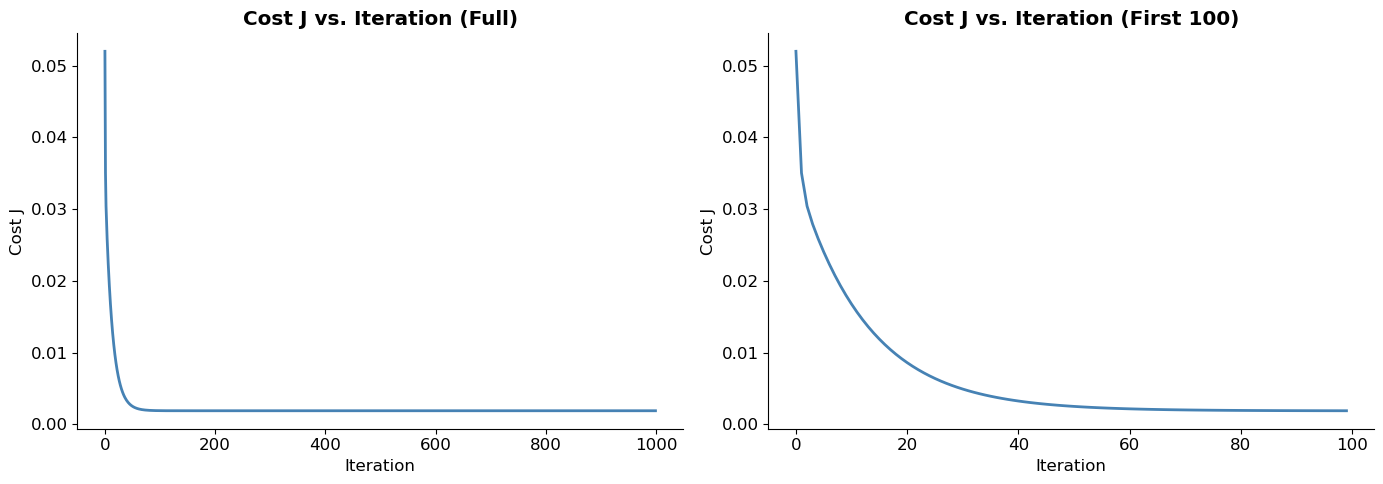

In [47]:
# ✏️ Task 7 — Plot cost vs. iteration number

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Full cost curve ────────────────────────────────────────────
axes[0].set_title("Cost J vs. Iteration (Full)", fontweight='bold')
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Cost J")

# plot model.cost_history on axes[0]
# Full cost curve
axes[0].plot(model.cost_history, color='steelblue', linewidth=2)

# ── Right: First 100 iterations (zoom in) ────────────────────────────
axes[1].set_title("Cost J vs. Iteration (First 100)", fontweight='bold')
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Cost J")

# YOUR CODE HERE — plot only the first 100 values of model.cost_history
# Zoomed first 100 iterations
axes[1].plot(model.cost_history[:100], color='steelblue', linewidth=2)


plt.tight_layout()
plt.show()


---
## 🔮 Step 8 — Make Predictions & Unscale

Our model predicts **scaled salary** (0 to 1).  
We need to convert back to **real USD** using the inverse of Min-Max scaling:

$$\hat{y}_{\text{USD}} = \hat{y}_{\text{scaled}} \times (\text{sal\_max} - \text{sal\_min}) + \text{sal\_min}$$


In [18]:
# ── 📘 DEMO: How to unscale predictions ──────────────────────────────
# sal_min and sal_max were saved in Step 3
print(f"sal_min = {sal_min:,.0f},  sal_max = {sal_max:,.0f}")

# Example: if model predicts scaled_value = 0.6
example_scaled = 0.6
example_usd = example_scaled * (sal_max - sal_min) + sal_min
print(f"Scaled prediction 0.6 → ${example_usd:,.0f} USD")


sal_min = 37,731,  sal_max = 122,391
Scaled prediction 0.6 → $88,527 USD


In [48]:
# ✏️ Task 8 — Predict on test set, then unscale

# Step 1: Get scaled predictions on X_test
y_pred_scaled = model.predict(X_test)   

# Step 2: Unscale predictions → real USD
y_pred_usd = y_pred_scaled * (sal_max - sal_min) + sal_min

# Step 3: Unscale the true test labels → real USD
y_test_usd = y_test * (sal_max - sal_min) + sal_min


# ── Auto-check ───────────────────────────────────────────────────────
assert y_pred_scaled is not None, "y_pred_scaled is None — call model.predict()"
assert y_pred_usd is not None,    "y_pred_usd is None — unscale the prediction"
assert y_test_usd is not None,    "y_test_usd is None — unscale the labels"
print("✅ Predictions computed!")
print()
print("Sample predictions vs actuals (USD):")
for i in range(min(5, len(y_test_usd))):
    print(f"  Predicted: ${y_pred_usd[i]:>9,.0f}  |  Actual: ${y_test_usd[i]:>9,.0f}  |  Error: ${abs(y_pred_usd[i]-y_test_usd[i]):,.0f}")


✅ Predictions computed!

Sample predictions vs actuals (USD):
  Predicted: $  115,790  |  Actual: $  112,635  |  Error: $3,155
  Predicted: $   71,498  |  Actual: $   67,938  |  Error: $3,560
  Predicted: $  102,597  |  Actual: $  113,812  |  Error: $11,215
  Predicted: $   75,268  |  Actual: $   83,088  |  Error: $7,820
  Predicted: $   55,478  |  Actual: $   64,445  |  Error: $8,967


---
## 📏 Step 9 — Evaluate Your Model

### Three key metrics:

| Metric | Formula | What it tells you |
|--------|---------|-------------------|
| **MSE** | (1/m) Σ (ŷ−y)² | Average squared error (same units²) |
| **RMSE** | √MSE | Average error in original units (USD) |
| **R²** | 1 − SS_res/SS_tot | % of variance explained (1.0 = perfect) |

Where:
- SS_res = Σ(ŷ−y)²  (residual sum of squares)
- SS_tot = Σ(y−ȳ)²  (total sum of squares)


In [24]:
# ✏️ Task 9 — Compute MSE, RMSE, and R² manually (no sklearn yet!)

m_test = len(y_test_usd)

# ── MSE ───────────────────────────────────────────────────────────────
mse = (1 / m_test) * np.sum( (y_pred_usd - y_test_usd) ** 2 )

# ── RMSE ── show average error kitne dollars hai
rmse = np.sqrt(mse)

# ── R² ── show hamara model data ke patterns ko bohot achi tarah capture kar raha hai
SS_res = np.sum( (y_pred_usd - y_test_usd)**2 )
SS_tot = np.sum( (y_test_usd - np.mean(y_test_usd))**2 )
r2 = 1 - (SS_res / SS_tot)


assert mse  is not None, "MSE is None — fill in the formula"
assert rmse is not None, "RMSE is None — take the sqrt of MSE"
assert r2   is not None, "R² is None — use the SS_res / SS_tot formula"

print("=" * 40)
print("  YOUR MODEL PERFORMANCE")
print("=" * 40)
print(f"  MSE  : {mse:>12,.2f}")
print(f"  RMSE : ${rmse:>10,.2f}  ← average error in USD")
print(f"  R²   : {r2:>12.4f}  ← closer to 1.0 = better")
print("=" * 40)


  YOUR MODEL PERFORMANCE
  MSE  : 49,830,096.86
  RMSE : $  7,059.04  ← average error in USD
  R²   :       0.9024  ← closer to 1.0 = better


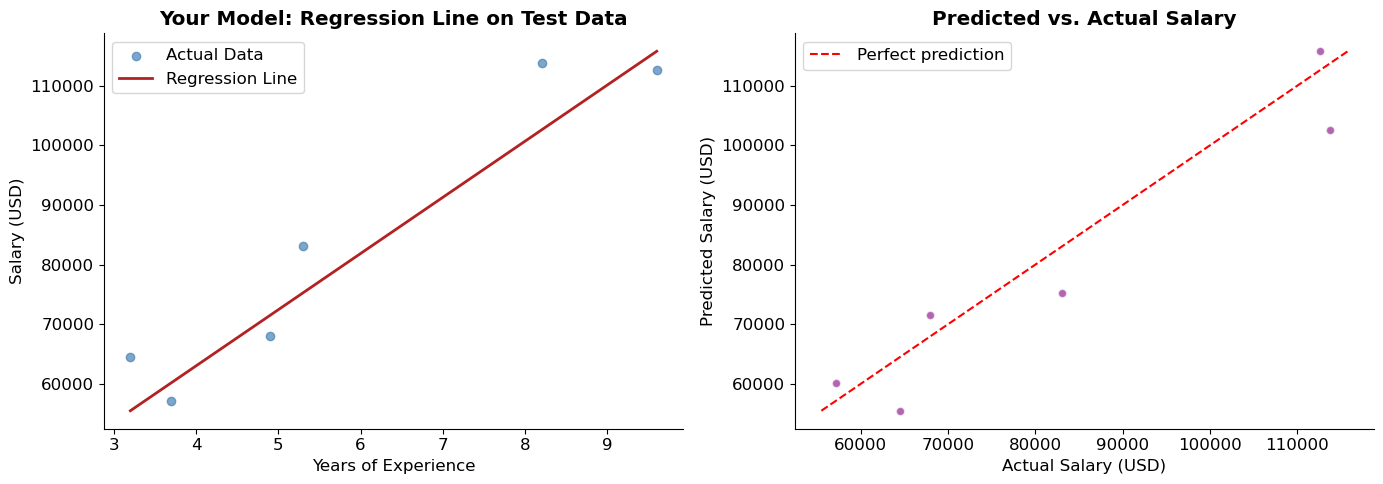

In [26]:
# ✏️ Task 9.2 — Visualise predictions vs actuals

# Unscale X_test for plotting (back to real experience years)
X_test_years = X_test * (exp_max - exp_min) + exp_min

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Scatter + regression line ──────────────────────────────────
axes[0].set_title("Your Model: Regression Line on Test Data", fontweight='bold')
axes[0].set_xlabel("Years of Experience")
axes[0].set_ylabel("Salary (USD)")

# scatter plot: X_test_years vs y_test_usd 
axes[0].scatter(X_test_years, y_test_usd, color='steelblue', label='Actual Data', alpha=0.7)

# regression line: sort X_test_years, plot vs y_pred_usd
# (You'll need to sort both arrays together)
sort_idx = np.argsort(X_test_years)
axes[0].plot(X_test_years[sort_idx], y_pred_usd[sort_idx], color='firebrick', linewidth=2, label='Regression Line')
axes[0].legend()

# ── Right: Predicted vs Actual (perfect model = diagonal line) ───────
axes[1].set_title("Predicted vs. Actual Salary", fontweight='bold')
axes[1].set_xlabel("Actual Salary (USD)")
axes[1].set_ylabel("Predicted Salary (USD)")

# scatter plot of y_test_usd vs y_pred_usd
axes[1].scatter(y_test_usd, y_pred_usd, color='purple', alpha=0.6, edgecolors='white')

# Perfect prediction line (diagonal)
mn = min(y_test_usd.min(), y_pred_usd.min())
mx = max(y_test_usd.max(), y_pred_usd.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 🔬 Step 10 — Compare with `sklearn` LinearRegression

Now we'll train sklearn's `LinearRegression` on the same data and compare.

> **sklearn** uses the **Normal Equation** (an analytical closed-form solution), not gradient descent.  
> The Normal Equation directly solves: **θ = (XᵀX)⁻¹ Xᵀy** in one step.  
> Your model uses iterative gradient descent — so results will be very similar but may differ slightly.


In [22]:
# ── Train sklearn's LinearRegression (the 'correct answer') ─────────

# sklearn expects 2D arrays for X
X_train_2d = X_train.reshape(-1, 1)
X_test_2d  = X_test.reshape(-1, 1)

sk_model = LinearRegression()
sk_model.fit(X_train_2d, y_train)

# sklearn predictions (scaled)
sk_pred_scaled = sk_model.predict(X_test_2d)

# Unscale → USD
sk_pred_usd = sk_pred_scaled * (sal_max - sal_min) + sal_min

sk_rmse = np.sqrt(mean_squared_error(y_test_usd, sk_pred_usd))
sk_r2   = r2_score(y_test_usd, sk_pred_usd)

print("=" * 50)
print("  SIDE-BY-SIDE COMPARISON")
print("=" * 50)
print(f"{'Metric':<12}  {'Your GD Model':>16}  {'sklearn':>16}")
print("-" * 50)
print(f"{'RMSE ($)':<12}  {rmse:>16,.2f}  {sk_rmse:>16,.2f}")
print(f"{'R²':<12}  {r2:>16.4f}  {sk_r2:>16.4f}")
print("=" * 50)

diff_r2 = abs(r2 - sk_r2)
print()
if diff_r2 < 0.01:
    print("✅ Excellent! Your model is within 1% R² of sklearn.")
elif diff_r2 < 0.05:
    print("⚠️  Close! Within 5% of sklearn. Try more iterations or a different α.")
else:
    print("❌ Large gap. Check your gradient formulas and cost history.")


  SIDE-BY-SIDE COMPARISON
Metric           Your GD Model           sklearn
--------------------------------------------------
RMSE ($)              7,059.04          7,059.04
R²                      0.9024            0.9024

✅ Excellent! Your model is within 1% R² of sklearn.


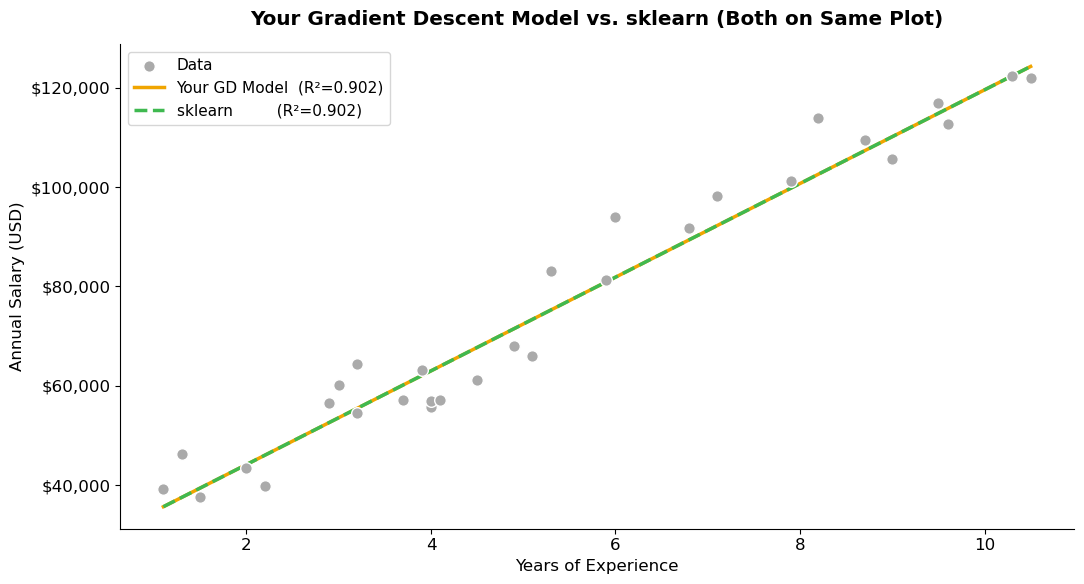

In [23]:
# ── Visual Comparison: Both regression lines on the same plot ───────────

# Unscale full dataset for plotting
X_all_years = x_scaled * (exp_max - exp_min) + exp_min

# Your model's prediction across full range
X_range_scaled = np.linspace(0, 1, 200)
X_range_years  = X_range_scaled * (exp_max - exp_min) + exp_min

your_line_usd  = model.predict(X_range_scaled)  * (sal_max - sal_min) + sal_min
sk_line_usd    = sk_model.predict(X_range_scaled.reshape(-1,1)) * (sal_max - sal_min) + sal_min

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_title("Your Gradient Descent Model vs. sklearn (Both on Same Plot)", fontweight='bold', pad=14)
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Annual Salary (USD)")

# All data points
ax.scatter(X_all_years, salary, color='#aaaaaa', edgecolors='white',
           s=70, zorder=3, label='Data')

# Your model
ax.plot(X_range_years, your_line_usd,
        color='#f0a500', linewidth=2.5, label=f'Your GD Model  (R²={r2:.3f})')

# sklearn
ax.plot(X_range_years, sk_line_usd,
        color='#3fb950', linewidth=2.5, linestyle='--', label=f'sklearn         (R²={sk_r2:.3f})')

ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


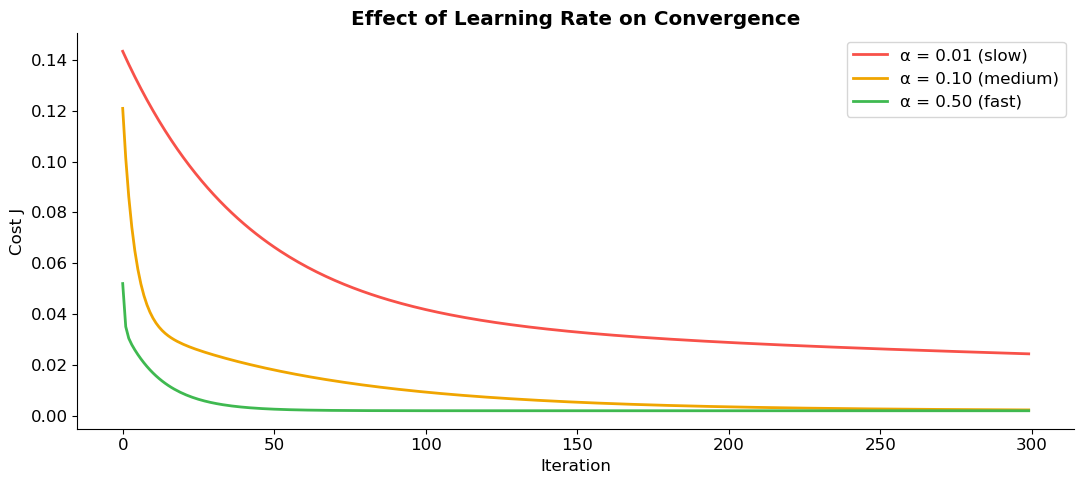

Observations:
  α = 0.01 → cost decreases slowly (too small)
  α = 0.10 → moderate convergence
  α = 0.50 → fast convergence (but watch for overshooting!)


In [25]:
# ✏️ Task 10 — Experiment: Effect of Learning Rate
# Train 3 models with different learning rates and plot their cost curves

learning_rates = [0.01, 0.1, 0.5]
colors = ['#f85149', '#f0a500', '#3fb950']
labels = ['α = 0.01 (slow)', 'α = 0.10 (medium)', 'α = 0.50 (fast)']

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title("Effect of Learning Rate on Convergence", fontweight='bold')
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J")

for lr, color, label in zip(learning_rates, colors, labels):
    # create a LinearRegressionGD with this lr and 300 iterations
    #                  fit it on X_train, y_train
    #                  plot its cost_history on ax

    exp_model = LinearRegressionGD(learning_rate=lr, n_iterations=300)
    exp_model.fit(X_train, y_train)
    ax.plot(exp_model.cost_history, color=color, linewidth=2, label=label)
    
ax.legend()
plt.tight_layout()
plt.show()

print("Observations:")
print("  α = 0.01 → cost decreases slowly (too small)")
print("  α = 0.10 → moderate convergence")
print("  α = 0.50 → fast convergence (but watch for overshooting!)")


---
## 🤔 Step 11 — Reflection Questions

Answer these in the cells below (as comments or print statements).

**Q1.** In your `fit()` method, what would happen if you did NOT use the simultaneous update (i.e., you updated `theta0` first and then used the new `theta0` to compute `grad1`)?

**Q2.** Your model trained on **scaled** features. If you skipped scaling and trained on raw salary values (39000–122000), what do you think would happen? Would it still converge?

**Q3.** Looking at your cost curve — how many iterations did it take to "mostly converge" (flatten out)?

**Q4.** Your R² score tells you what % of the variance in salary is explained by experience alone. What other features might explain the remaining variance?

**Q5.** sklearn's `LinearRegression` uses the Normal Equation (no iterations). What is one advantage of gradient descent over the Normal Equation for very large datasets?


In [13]:
# ✏️ Answer Q1 — Simultaneous vs Sequential Update

# YOUR ANSWER HERE (write as a comment or string)
q1 = """
If we don't update them simultaneously,the model can become unstable. Gradient Descent math relies on the fact that all parameters (theta_0, theta_1) are updated based on the same previous position. If you change one first, the second one is updated based on a new point, which can make the model "lose its way" or slow down the process of finding the best answer."""
print("Q1:", q1)


Q1: 
If we don't update them simultaneously,the model can become unstable. Gradient Descent math relies on the fact that all parameters (theta_0, theta_1) are updated based on the same previous position. If you change one first, the second one is updated based on a new point, which can make the model "lose its way" or slow down the process of finding the best answer.


In [19]:
# ✏️ Answer Q2 — Effect of skipping feature scaling

q2 = """
The model would likely fail to converge (Diverge).Raw values are very large,and since Gradient Descent involves multiplication,the gradients would become huge. This causes the model to "explode" (values become too big for the computer to handle). Scaling keeps everything between 0 and 1, helping Gradient Descent find the right path smoothly and quickly.
"""
print("Q2:", q2)


Q2: 
The model would likely fail to converge (Diverge).Raw values are very large,and since Gradient Descent involves multiplication,the gradients would become huge. This causes the model to "explode" (values become too big for the computer to handle). Scaling keeps everything between 0 and 1, helping Gradient Descent find the right path smoothly and quickly.



In [21]:
# ✏️ Answer Q3 — Iterations to convergence

q3 = """
Looking at your graph(the first 100 iterations),the curve becomes mostly flat after about 40 to 60 iterations.This means the model did most of its "learning" in those first 60 steps."""
print("Q3:", q3)


Q3: 
Looking at your graph(the first 100 iterations),the curve becomes mostly flat after about 40 to 60 iterations.This means the model did most of its "learning" in those first 60 steps.


In [22]:
# ✏️ Answer Q4 — Other features that affect salary

q4 = """
Salary isn't just about experience. Other factors that could explain the difference include:

Education Level (e.g., Master's vs. Bachelor's degree).

Job Title/Role (e.g., Manager vs. Junior Developer).

Location (Salaries differ by city or country).

Company Size (Big corporations vs. small startups).

Technical Skills (Specific high-demand programming languages).
"""
print("Q4:", q4)


Q4: 
Salary isn't just about experience. Other factors that could explain the difference include:

Education Level (e.g., Master's vs. Bachelor's degree).

Job Title/Role (e.g., Manager vs. Junior Developer).

Location (Salaries differ by city or country).

Company Size (Big corporations vs. small startups).

Technical Skills (Specific high-demand programming languages).



In [27]:
# ✏️ Answer Q5 — GD vs Normal Equation

q5 = """
The Normal Equation requires Matrix Inversion,which becomes extremely slow and uses too much RAM(memory) when the dataset is huge.Gradient Descent is much more memory-efficient.It can learn from data in small pieces(batches),allowing it to work on massive datasets with billions of rows without crashing the computer.
"""
print("Q5:", q5)


Q5: 
The Normal Equation requires Matrix Inversion,which becomes extremely slow and uses too much RAM(memory) when the dataset is huge.Gradient Descent is much more memory-efficient.It can learn from data in small pieces(batches),allowing it to work on massive datasets with billions of rows without crashing the computer.



---
## 🌟 Bonus Challenge (Optional)

### 1. Stochastic Gradient Descent

Modify your class (or create `SGDLinearRegression`) to use **stochastic** gradient descent — update parameters using **one random sample at a time** instead of the full batch.

Compare the cost curves of Batch GD vs SGD. Which is noisier?

### 2. Early Stopping

Add an `early_stopping` parameter to `__init__`. If the cost improvement between iterations is less than `tolerance = 1e-6`, stop training early and print how many iterations it actually took.

### 3. Mini-Batch Gradient Descent

Implement mini-batch GD with a configurable `batch_size` parameter.  
Test with `batch_size = 8` and compare with full-batch.


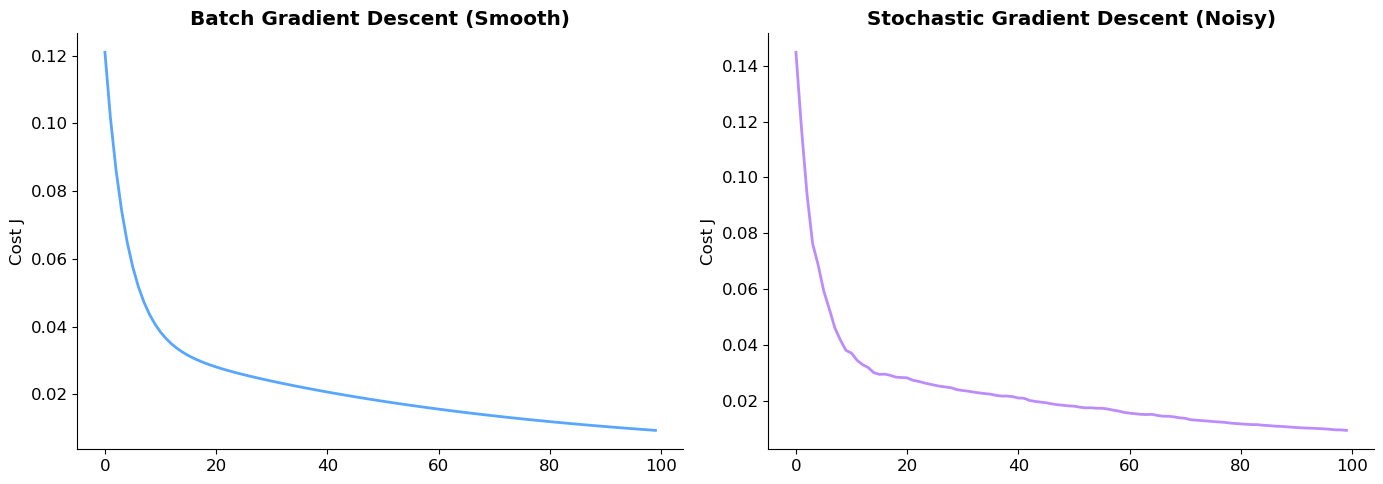

In [28]:
# 🌟 BONUS — Stochastic Gradient Descent class

class SGDLinearRegression:
    """Linear Regression with Stochastic Gradient Descent (1 sample per update)."""

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.theta0 = 0.0
        self.theta1 = 0.0
        self.cost_history = []

    def fit(self, X, y):
        m = len(y)
        for i in range(self.n_iter):
            # Pick ONE random sample index
            idx = np.random.randint(0, m)
            xi  = X[idx]
            yi  = y[idx]

            # compute prediction and error for just sample idx
            pred  = self.theta0 + self.theta1 * xi
            error = pred - yi

            # gradient for 1 sample (no 1/m average needed)
            grad0 = error
            grad1 = error * xi

            # simultaneous update
            self.theta0 = self.theta0 - self.lr * grad0
            self.theta1 = self.theta1 - self.lr * grad1

            # Record full batch cost every 10 steps (for comparison)
            if i % 10 == 0:
                full_cost = (1/(2*m)) * np.sum((self.theta0 + self.theta1*X - y)**2)
                self.cost_history.append(full_cost)

        return self


# ── Compare SGD vs Batch GD cost curves ──────────────────────────────
# YOUR CODE HERE — train both, plot side by side
# 1. Batch Gradient Descent train karein
batch_model = LinearRegressionGD(learning_rate=0.1, n_iterations=100)
batch_model.fit(X_train, y_train)

# 2. SGD train karein (ziyada iterations chahiye kyunke ye per-sample chalta hai)
sgd_model = SGDLinearRegression(learning_rate=0.01, n_iterations=1000)
sgd_model.fit(X_train, y_train)

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Batch GD Plot
axes[0].plot(batch_model.cost_history, color='#58a6ff', linewidth=2)
axes[0].set_title("Batch Gradient Descent (Smooth)", fontweight='bold')
axes[0].set_ylabel("Cost J")

# SGD Plot
axes[1].plot(sgd_model.cost_history, color='#bc8cff', linewidth=2)
axes[1].set_title("Stochastic Gradient Descent (Noisy)", fontweight='bold')
axes[1].set_ylabel("Cost J")

plt.tight_layout()
plt.show()

---
## ✅ Summary — What You Built

Congratulations! Here's what you implemented from scratch:

| Component | Formula |
|---|---|
| **Hypothesis** | hθ(x) = θ₀ + θ₁x |
| **Cost** | J = (1/2m) Σ (hθ(xⁱ) − yⁱ)² |
| **Gradient θ₀** | ∂J/∂θ₀ = (1/m) Σ (hθ(xⁱ) − yⁱ) |
| **Gradient θ₁** | ∂J/∂θ₁ = (1/m) Σ (hθ(xⁱ) − yⁱ) · xⁱ |
| **Update rule** | θ := θ − α · ∂J/∂θ |

Your gradient descent model should achieve **R² ≥ 0.95** on this dataset — almost identical to sklearn's closed-form solution! 🎉

---
*This notebook was built to accompany the Linear Regression lecture. Keep it as a reference for future implementations.*
